In [1]:
import os
os.chdir('../../..')

In [ ]:
import numpy as np
import polars as pl

from scipy.spatial.distance import squareform
import plotly.graph_objects as go
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

from src.datasets import MaterialsProject
from scripts.materials_project.evaluation_pipeline import (run_evaluation, 
                                                           hierachial_clustering, 
                                                           get_overall_chemical_coherence, 
                                                           get_distance_matrices
                                                           )
from src.helper_functions import create_chemiscope_viewer

In [3]:
# mp = MaterialsProject()
# df = mp.load(force_fetch=True, limit=None)

In [4]:
mp = MaterialsProject(add_soap=True, add_acsf=False, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"])
df = mp.load(limit=1000)

2026-03-30 15:51:31.064 | INFO     | src.datasets:load:1030 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-30 15:51:31.855 | INFO     | src.datasets:load:1060 - Sampling 1000 rows using stratified strategy...
2026-03-30 15:51:31.954 | INFO     | src.datasets:load:1077 - Computing descriptors on sampled subset (1000 rows) and saving to tagged cache: sample_n1000_seed40_stratified
2026-03-30 15:51:31.955 | INFO     | src.datasets:_add_descriptors:1321 - Ignoring output_tag=sample_n1000_seed40_stratified since descriptors are not saved to disk.
2026-03-30 15:51:31.955 | INFO     | src.datasets:_add_descriptors:1324 - Extracting unique elements from formulas...
2026-03-30 15:51:47.151 | INFO     | src.datasets:_add_descriptors:1334 - Found 85 unique elements. Warning: Feature vectors will be massive.
2026-03-30 15:51:47.154 | INFO     | src.datasets:_add_descriptors:1365 - Computing SOAP chunk 0 (0 to 1000)...
2026-03-30 15:51:49.479 | SUCCESS  

In [5]:
distance_matrices = get_distance_matrices(df, force_recompute=False)
distance_matrices.keys()

2026-03-30 15:51:49.495 | INFO     | scripts.materials_project.evaluation_pipeline:get_distance_matrices:359 - Loading cached SOAP distances from data/Materials Project/soap_distances/default_1000_55b38f34b627.npz...
2026-03-30 15:51:49.496 | INFO     | scripts.materials_project.evaluation_pipeline:get_distance_matrices:360 - Loading cached invariant distances from data/Materials Project/invariant_distances/default_1000_55b38f34b627.npz...


dict_keys(['soap_pca', 'soap_tsne', 'soap_umap', 'soap_isomap', 'invariant_aggregated', 'invariant_riemann', 'invariant_grassmann', 'invariant_wasserstein'])

In [96]:
dist_matrix = distance_matrices['soap_tsne']
condensed_dist = squareform(dist_matrix)
reduction_technique = 'PCA'
linkage_type = 'complete'

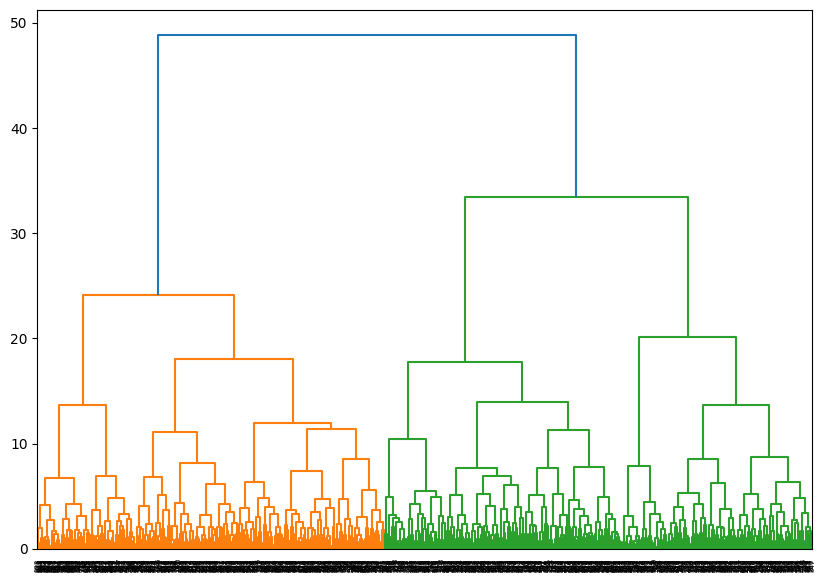

In [97]:
Z = linkage(condensed_dist, method=linkage_type)
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.show()

Clustering: 100%|██████████| 98/98 [00:03<00:00, 32.51it/s]


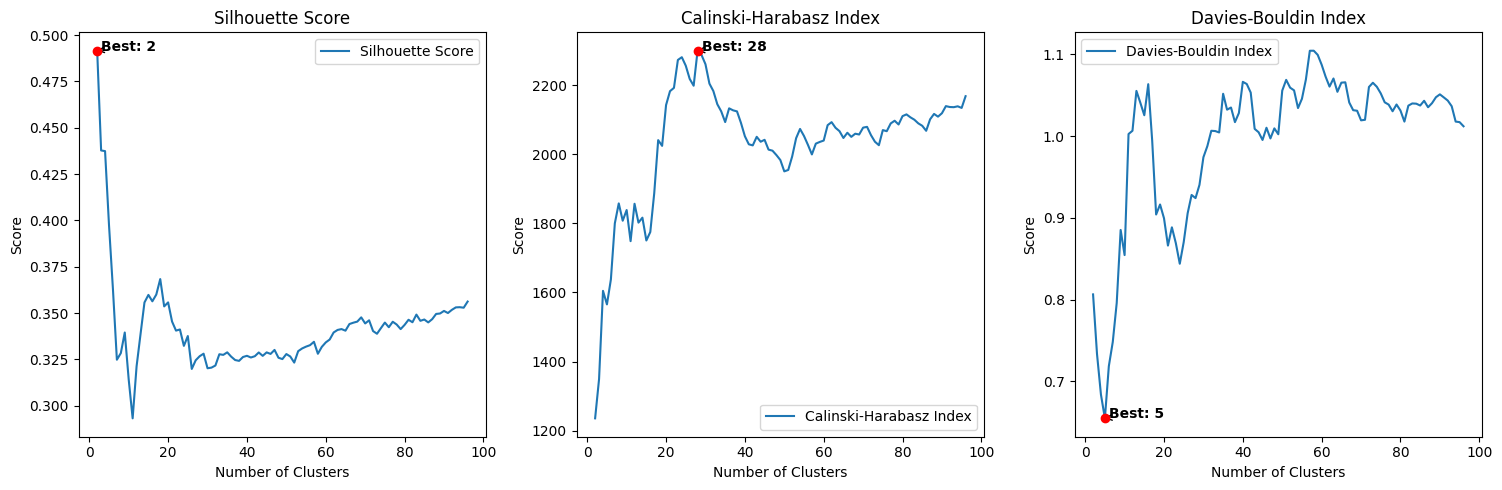

In [98]:
eval_scores = run_evaluation(dist_matrix, linkage=linkage_type) # best number of clusters : ...

In [75]:
n_clusters = 27
metrics = {'sil': [], 'ch': [], 'db': []}
cluster_n_metrics = {key: values[n_clusters-2] for key, values in eval_scores.items()}

hier_labels = hierachial_clustering(dist_matrix, n_clusters=n_clusters, linkage=linkage_type)
random_labels = np.random.randint(0, n_clusters, size=len(df))
chemical_hier_coherence, average_hier_coherence = get_overall_chemical_coherence(df, hier_labels)
chemical_random_coherence, average_random_coherence = get_overall_chemical_coherence(df, random_labels)

In [ ]:
# df = df.with_columns(pl.Series(name='hier_labels', values=hier_labels))
# for i in range(n_clusters):
#     print(f"Cluster {i}:")
#     display(df.filter(pl.col('hier_labels') == i).select(['formula_pretty', 'space_group', 'band_gap', 'formation_energy_per_atom']).head(10))
#     display(df.filter(pl.col('hier_labels') == i).select(['formula_pretty', 'space_group', 'band_gap', 'formation_energy_per_atom']).tail(10))

In [76]:
print("Hierarchical Clustering Coherence:", chemical_hier_coherence)
print("Average Hierarchical Clustering Coherence:", average_hier_coherence)
print("Random Clustering Coherence:", chemical_random_coherence)
print("Average Random Clustering Coherence:", average_random_coherence)

Hierarchical Clustering Coherence: {'band_gap': 0.6003870580904613, 'density': 0.7221332282692695, 'energy_per_atom': 0.7081269127810268, 'formation_energy_per_atom': 0.5880528850534422, 'volume': 0.5416462323869051, 'energy_above_hull': 0.6076866819695352, 'is_metal': 0.723}
Average Hierarchical Clustering Coherence: 0.6415761426500914
Random Clustering Coherence: {'band_gap': 0.5046387979641753, 'density': 0.5070543908156786, 'energy_per_atom': 0.5105246990597965, 'formation_energy_per_atom': 0.5037131027974177, 'volume': 0.5204142983743951, 'energy_above_hull': 0.5856612262368499, 'is_metal': 0.569}
Average Random Clustering Coherence: 0.5287152164640447


In [77]:
create_chemiscope_viewer(df, dist_matrix, hier_labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP t-SNE Clustering'}, settings={'map': {'x': {'propert…

In [44]:
def plot_coherence_radar(hier_coherence, random_coherence):
    # 1. Extract the features (categories)
    categories = list(hier_coherence.keys())
    
    # 2. Extract the values 
    hier_vals = list(hier_coherence.values())
    random_vals = list(random_coherence.values())
    
    # 3. FIX: Close the loop so the outer line connects back to the start!
    categories.append(categories[0])
    hier_vals.append(hier_vals[0])
    random_vals.append(random_vals[0])
    
    fig = go.Figure()

    # Add Hierarchical Trace
    fig.add_trace(go.Scatterpolar(
        r=hier_vals,
        theta=categories,
        fill='toself',
        name='Hierarchical Clustering',
        line=dict(color='royalblue', width=2),
        fillcolor='rgba(65, 105, 225, 0.3)' # Transparent blue
    ))

    # Add Random Baseline Trace
    fig.add_trace(go.Scatterpolar(
        r=random_vals,
        theta=categories,
        fill='toself',
        name='Random Baseline',
        line=dict(color='crimson', width=2, dash='dot'),
        fillcolor='rgba(220, 20, 60, 0.1)' # Highly transparent red
    ))

    # Layout and Formatting
    fig.update_layout(
        title=dict(
            text='Chemical Coherence Comparison: Hierarchical vs. Random',
            font=dict(size=20),
            y=0.95,
            x=0.5,
            xanchor='center',
            yanchor='top'
        ),
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1], # Since your coherence scores are 0 to 1
                tickfont=dict(size=10),
                tickangle=0,
                tickcolor='rgba(0,0,0,0.2)'
            ),
            angularaxis=dict(
                tickfont=dict(size=12, color='black')
            )
        ),
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.15,
            xanchor="center",
            x=0.5
        ),
        template='plotly_white',
        width=700,
        height=700
    )
    
    fig.show()

plot_coherence_radar(chemical_hier_coherence, chemical_random_coherence)

In [13]:
import plotly.graph_objects as go

def plot_normalized_structural_metrics(eval_scores, n_clusters):
    """
    Normalizes the structural metrics for a specific number of clusters 
    relative to all tested configurations, and plots a closed radar chart.
    """
    # If your tests started at n=2, then n_clusters=4 is index 2
    target_index = n_clusters - 2 
    
    categories = []
    normalized_values = []
    raw_values_for_hover = []
    
    # 1. Normalize based on the min/max of the full eval_scores
    for metric_name, values in eval_scores.items():
        val = values[target_index]
        v_min = min(values)
        v_max = max(values)
        
        if v_max == v_min:
            norm_val = 0.5 
        elif metric_name == 'db':
            # DB: Lower is better, so we invert the normalization
            norm_val = (v_max - val) / (v_max - v_min)
            categories.append(f"{metric_name.upper()}<br>(Lower=Better)")
        else:
            # SIL and CH: Higher is better
            norm_val = (val - v_min) / (v_max - v_min)
            categories.append(f"{metric_name.upper()}<br>(Higher=Better)")
            
        normalized_values.append(norm_val)
        raw_values_for_hover.append(val)
        
    # 2. Close the loop for Plotly!
    normalized_values.append(normalized_values[0])
    categories.append(categories[0])
    raw_values_for_hover.append(raw_values_for_hover[0])

    # 3. Create the Plotly Radar Plot
    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=normalized_values,
        theta=categories,
        fill='toself',
        name=f'{n_clusters} Clusters',
        line=dict(color='darkorange', width=2),
        fillcolor='rgba(255, 140, 0, 0.4)',
        customdata=raw_values_for_hover,
        hovertemplate=(
            "<b>%{theta}</b><br>"
            "Normalized Score: %{r:.2f}<br>"
            "Raw Value: %{customdata:.3f}<extra></extra>"
        )
    ))

    # 4. Layout and Formatting
    fig.update_layout(
        title=dict(
            text=f'Structural Performance: {n_clusters} Clusters (Relative Scale)',
            font=dict(size=18),
            y=0.95,
            x=0.5,
            xanchor='center',
            yanchor='top'
        ),
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickfont=dict(size=10),
                tickcolor='rgba(0,0,0,0.2)'
            ),
            angularaxis=dict(
                tickfont=dict(size=12, color='black')
            )
        ),
        showlegend=False,
        template='plotly_white',
        width=500,
        height=500
    )
    
    fig.show()

n_clusters = 4
plot_normalized_structural_metrics(eval_scores, n_clusters)